# MAKE A COPY DULU YA GUYS

# Workshop Notebook: Intro to Deep Learning dan Computer Vision dengan TensorFlow

Notebook ini dirancang sebagai pendamping workshop **basic deep learning** dan **basic computer vision**.  
Alurnya disusun agar mengikuti materi presentasi secara bertahap:

1. **Intro to Deep Learning**
2. **TensorFlow sebagai framework**
3. **Neuron, layer, forward pass, activation function**
4. **Loss function, optimizer, dan backpropagation**
5. **Arsitektur dasar: MLP dan CNN**
6. **Intro to Computer Vision**
7. **Bagaimana komputer melihat gambar**
8. **General flow computer vision**
9. **Implementasi klasifikasi gambar sederhana dengan TensorFlow**

> Fokus notebook ini adalah **pemahaman konsep + implementasi dasar yang runnable di Colab/Jupyter**.

## Tujuan Belajar

Setelah menyelesaikan notebook ini, peserta diharapkan mampu:

- memahami perbedaan **Machine Learning**, **Deep Learning**, dan **Computer Vision**,
- menjelaskan peran **neuron**, **layer**, **forward pass**, **activation function**, **loss**, **optimizer**, dan **backpropagation**,
- memahami mengapa **CNN** cocok untuk data gambar,
- mengenali bagaimana gambar direpresentasikan sebagai **angka/pixel**,
- membangun model **MLP** dan **CNN** sederhana menggunakan **TensorFlow/Keras**,
- membandingkan performa model dasar pada tugas **image classification**.

---

## Peta Konsep Workshop

| Bagian | Inti Materi | Output yang Diharapkan |
|---|---|---|
| Part 1 | Intro Deep Learning | Paham dasar neural network |
| Part 2 | TensorFlow | Bisa mulai implementasi model |
| Part 3 | Forward pass, activation, loss, optimizer | Paham proses belajar model |
| Part 4 | MLP vs CNN | Paham arsitektur dasar |
| Part 5 | Computer Vision | Paham representasi gambar |
| Part 6 | Implementasi TensorFlow | Bisa membuat model klasifikasi gambar sederhana |

## 1. Deep Learning dalam Ekosistem AI

Secara umum, relasinya bisa dibaca seperti ini:

**Artificial Intelligence → Machine Learning → Deep Learning**

- **Artificial Intelligence (AI)** adalah payung besar untuk sistem yang meniru kemampuan cerdas manusia.
- **Machine Learning (ML)** adalah bagian dari AI yang belajar dari data.
- **Deep Learning (DL)** adalah bagian dari ML yang menggunakan **jaringan saraf tiruan** dengan beberapa layer.

### Ringkasan Perbedaan ML vs DL

| Aspek | Machine Learning Tradisional | Deep Learning |
|---|---|---|
| Fitur | Sering perlu feature engineering manual | Fitur dapat dipelajari otomatis |
| Jenis data | Cocok untuk tabular dan kasus sederhana | Sangat kuat untuk gambar, audio, teks |
| Kebutuhan data | Relatif lebih sedikit | Biasanya lebih banyak |
| Komputasi | Lebih ringan | Lebih berat |
| Interpretasi | Sering lebih mudah | Biasanya lebih kompleks |

### Pro dan Kontra Deep Learning

| Kelebihan | Kekurangan |
|---|---|
| Kuat untuk data tidak terstruktur seperti gambar, suara, video, teks | Bisa berlebihan untuk tabular sederhana |
| Skalabilitas tinggi | Butuh data besar |
| Dapat memanfaatkan pretrained model | Cost komputasi lebih tinggi |

## 2. Kenapa TensorFlow?

Dalam materi workshop, TensorFlow diperkenalkan sebagai framework open-source dari Google untuk membangun sistem machine learning dan deep learning.

Di notebook ini, kita memakai **`tf.keras`**, yaitu API tingkat tinggi dari TensorFlow, karena:

- sintaksnya relatif mudah untuk pemula,
- cocok untuk workshop dan eksperimen cepat,
- banyak dokumentasi dan contoh,
- mendukung pipeline training yang rapi.

> Singkatnya: **TensorFlow membantu kita fokus ke ide model, bukan hanya detail implementasi matematisnya.**

In [ ]:
!pip install -q tensorflow

In [ ]:
# Jika TensorFlow belum tersedia di environment lokal, buka komentar baris berikut:
# !pip install -q tensorflow

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version :", tf.__version__)
print("NumPy version      :", np.__version__)
print("GPU available      :", tf.config.list_physical_devices("GPU"))

# Optional: cek detail GPU di Colab
# !nvidia-smi


TensorFlow version : 2.19.0
NumPy version      : 2.0.2
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Neuron: Unit Pemrosesan Paling Dasar

Secara sederhana, sebuah neuron melakukan tiga hal:

1. menerima input,
2. mengalikan tiap input dengan **weight**,
3. menjumlahkan semuanya, menambahkan **bias**, lalu melewatkannya ke **activation function**.

Secara matematis:

$$
z = \sum_i x_i w_i + b
$$

lalu output neuron menjadi:

$$
a = \phi(z)
$$

dengan:
- $x_i$ = input
- $w_i$ = weight
- $b$ = bias
- $\phi$ = activation function

### Intuisi sederhananya
Neuron itu seperti “unit pengambil keputusan kecil”.  
Ia menerima angka, menimbang pengaruh masing-masing angka, lalu mengeluarkan sinyal output.

In [ ]:
# Simulasi sederhana satu neuron dengan NumPy

x = np.array([0.8, 0.4, 0.2])          # 3 input
w = np.array([0.5, -0.3, 0.8])         # 3 weight
b = 0.1                                # bias

z = np.dot(x, w) + b                   # operasi linear
relu_output = np.maximum(0, z)         # aktivasi ReLU

print("Input          :", x)
print("Weight         :", w)
print("Bias           :", b)
print("Nilai linear z :", round(float(z), 4))
print("Output ReLU    :", round(float(relu_output), 4))

Input          : [0.8 0.4 0.2]
Weight         : [ 0.5 -0.3  0.8]
Bias           : 0.1
Nilai linear z : 0.54
Output ReLU    : 0.54


## 4. Layer pada Neural Network

Saat neuron-neuron digabungkan, kita mendapatkan **layer**.

### Jenis layer yang paling dasar

| Layer | Fungsi |
|---|---|
| Input Layer | menerima data mentah |
| Hidden Layer | mempelajari pola dan representasi internal |
| Output Layer | menghasilkan prediksi akhir |

Semakin banyak hidden layer, semakin besar kapasitas model untuk mempelajari pola yang kompleks.  
Namun, semakin besar model, biasanya kebutuhan data dan komputasi juga meningkat.

## 5. Forward Pass

**Forward pass** adalah proses ketika data bergerak dari **input layer** menuju **output layer**.

Alurnya:

**input → operasi linear → activation → layer berikutnya → ... → output**

Pada tahap ini, model belum “memperbaiki diri”.  
Model hanya menghasilkan **prediksi** berdasarkan weight dan bias yang saat itu dimiliki.

### Ringkasan alur training

```text
Input Data
   ↓
Forward Pass
   ↓
Activation Function
   ↓
Prediction
   ↓
Loss Function
   ↓
Optimizer + Backpropagation
   ↓
Update Weights
   ↓
Ulangi lagi
```

### Demo Kode: Forward Pass Sederhana

Pada contoh ini, kita buat **1 layer sederhana** secara manual:
- input berupa 2 sampel,
- masing-masing punya 3 fitur,
- lalu kita hitung:
  1. hasil operasi linear $z = XW + b$,
  2. output setelah aktivasi ReLU.

Dengan cara ini, peserta bisa melihat bahwa **forward pass hanyalah aliran komputasi dari input menjadi output**.


In [ ]:
# Demo forward pass manual untuk 1 dense layer
X_batch = np.array([
    [0.5, 1.0, -0.5],
    [1.5, -0.2, 0.3]
], dtype=np.float32)

W = np.array([
    [0.2, -0.4],
    [0.7,  0.1],
    [-0.5, 0.3]
], dtype=np.float32)

b = np.array([0.1, -0.2], dtype=np.float32)

# Operasi linear
Z = X_batch @ W + b

# Aktivasi ReLU
A = np.maximum(0, Z)

print("Input batch shape :", X_batch.shape)
print("Weight shape      :", W.shape)
print("Bias shape        :", b.shape)
print("\nHasil linear (Z):")
print(Z)
print("\nOutput setelah ReLU (A):")
print(A)

Input batch shape : (2, 3)
Weight shape      : (3, 2)
Bias shape        : (2,)

Hasil linear (Z):
[[ 1.15       -0.45      ]
 [ 0.11000001 -0.72999996]]

Output setelah ReLU (A):
[[1.15       0.        ]
 [0.11000001 0.        ]]


## 6. Activation Function

Activation function diperlukan agar model dapat mempelajari **hubungan non-linear**.  
Kalau semua layer hanya linear, maka network yang dalam pun secara efektif tetap setara dengan transformasi linear sederhana.

### Aktivasi yang sering dipakai

| Fungsi | Bentuk Output | Umum Dipakai Untuk |
|---|---|---|
| ReLU | \(\max(0, x)\) | hidden layer |
| Sigmoid | 0 sampai 1 | output biner / probabilitas |
| Softmax | probabilitas yang jumlahnya 1 | klasifikasi multikelas |
| Tanh | -1 sampai 1 | beberapa hidden layer / model klasik |

> Dalam praktik modern, **ReLU** sering dipakai di hidden layer karena sederhana dan efektif.

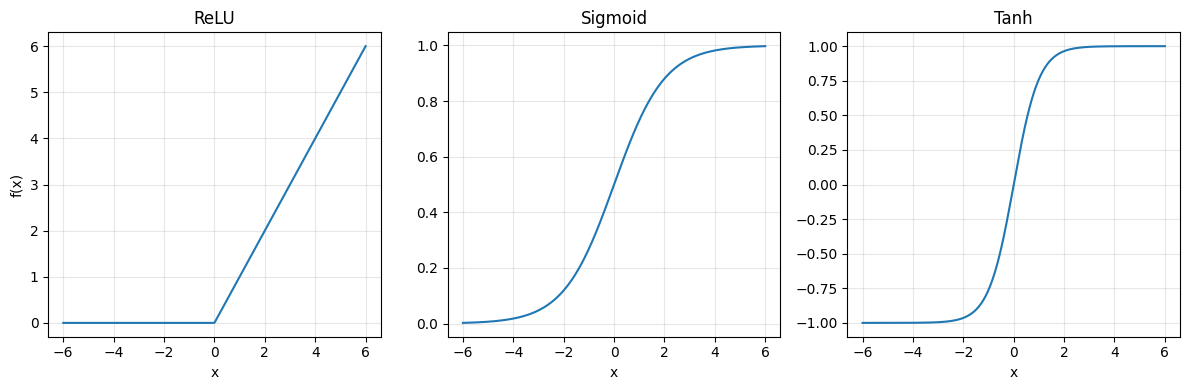

In [ ]:
# Visualisasi beberapa activation function

x = np.linspace(-6, 6, 400)
relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(x, relu)
plt.title("ReLU")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(x, sigmoid)
plt.title("Sigmoid")
plt.xlabel("x")
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(x, tanh)
plt.title("Tanh")
plt.xlabel("x")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Kenapa ReLU penting?

ReLU mengikuti ide pada slide workshop:  
jika input negatif, output menjadi 0; jika input positif, output tetap sama.  
Keunggulannya:

- perhitungannya sederhana,
- membantu model belajar lebih stabil,
- membantu mengurangi masalah **vanishing gradient** dibanding aktivasi lama tertentu.

## 7. Loss Function, Optimizer, dan Backpropagation

Tiga komponen ini adalah inti dari proses training.

### 7.1 Loss Function
Loss function mengukur **seberapa jauh prediksi model dari target sebenarnya**.

| Tugas | Contoh Loss |
|---|---|
| Regresi | MSE, MAE |
| Klasifikasi biner | Binary Crossentropy |
| Klasifikasi multikelas | Sparse/Categorical Crossentropy |
| Segmentasi | Dice Loss, Binary Crossentropy, dll. |

### 7.2 Optimizer
Optimizer bertugas memperbarui weight dan bias agar loss makin kecil.

Contoh optimizer populer:

- SGD
- Adam
- RMSprop
- Momentum

### 7.3 Backpropagation
Backpropagation menghitung **gradien** dari loss terhadap parameter model dari layer paling belakang ke depan.  
Gradien ini lalu dipakai optimizer untuk melakukan update.

Secara intuitif:

- kalau prediksi salah, model “diberi tahu” arah kesalahannya,
- lalu weight diubah sedikit demi sedikit,
- sehingga prediksi berikutnya diharapkan lebih baik.

> Jadi, **forward pass menghasilkan prediksi**, sedangkan **backpropagation membantu memperbaiki parameter**.

### Demo Kode: Menghitung Loss

Agar peserta tidak hanya melihat istilah *loss function*, kita hitung dua contoh sederhana:

1. **MSE** untuk kasus regresi  
2. **Sparse Categorical Crossentropy** untuk kasus klasifikasi multikelas

Tujuannya supaya terlihat bahwa loss adalah **angka yang mengukur seberapa jauh prediksi dari target sebenarnya**.


In [ ]:
# Demo 1: Mean Squared Error (MSE) untuk regresi
y_true_reg = tf.constant([[3.0], [0.5], [2.0]], dtype=tf.float32)
y_pred_reg = tf.constant([[2.5], [0.0], [2.2]], dtype=tf.float32)

mse_fn = tf.keras.losses.MeanSquaredError()
mse_value = mse_fn(y_true_reg, y_pred_reg)

print("=== Regresi ===")
print("y_true:", y_true_reg.numpy().reshape(-1))
print("y_pred:", y_pred_reg.numpy().reshape(-1))
print("MSE   :", float(mse_value))

# Demo 2: Sparse Categorical Crossentropy untuk klasifikasi multikelas
# Misal ada 3 sampel dan 3 kelas
y_true_cls = tf.constant([0, 2, 1], dtype=tf.int32)
y_pred_cls = tf.constant([
    [0.80, 0.15, 0.05],
    [0.10, 0.20, 0.70],
    [0.20, 0.60, 0.20]
], dtype=tf.float32)

sce_fn = tf.keras.losses.SparseCategoricalCrossentropy()
sce_value = sce_fn(y_true_cls, y_pred_cls)

print("\n=== Klasifikasi Multikelas ===")
print("y_true:", y_true_cls.numpy())
print("y_pred:")
print(y_pred_cls.numpy())
print("Sparse Categorical Crossentropy:", float(sce_value))

=== Regresi ===
y_true: [3.  0.5 2. ]
y_pred: [2.5 0.  2.2]
MSE   : 0.18000000715255737

=== Klasifikasi Multikelas ===
y_true: [0 2 1]
y_pred:
[[0.8  0.15 0.05]
 [0.1  0.2  0.7 ]
 [0.2  0.6  0.2 ]]
Sparse Categorical Crossentropy: 0.36354801058769226


### Demo Kode: Optimizer dan Satu Langkah Backpropagation

Di bagian ini kita tunjukkan proses yang paling penting saat training:

- model melakukan **forward pass**,
- loss dihitung,
- `GradientTape` merekam komputasi,
- gradien dihitung,
- optimizer memperbarui weight dan bias.

Kita gunakan model linear kecil agar proses update parameternya mudah diamati.


In [ ]:
# Demo optimizer + backpropagation dengan 1 langkah update
x_demo = tf.constant([[1.0], [2.0], [3.0], [4.0]], dtype=tf.float32)
y_demo = tf.constant([[2.0], [4.0], [6.0], [8.0]], dtype=tf.float32)  # target ideal: y = 2x

simple_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.SGD(learning_rate=0.1)
loss_fn = tf.keras.losses.MeanSquaredError()

initial_w, initial_b = simple_model.layers[0].get_weights()
print("Sebelum update")
print("Weight:", initial_w.ravel())
print("Bias  :", initial_b)

with tf.GradientTape() as tape:
    y_pred = simple_model(x_demo, training=True)
    loss_value = loss_fn(y_demo, y_pred)

grads = tape.gradient(loss_value, simple_model.trainable_variables)

print("\nLoss sebelum update:", float(loss_value))
print("Gradient weight:", grads[0].numpy().ravel())
print("Gradient bias  :", grads[1].numpy())

optimizer.apply_gradients(zip(grads, simple_model.trainable_variables))

updated_w, updated_b = simple_model.layers[0].get_weights()
print("\nSetelah 1 langkah update")
print("Weight:", updated_w.ravel())
print("Bias  :", updated_b)

Sebelum update
Weight: [1.2408034]
Bias  : [0.]

Loss sebelum update: 4.322846412658691
Gradient weight: [-11.387949]
Gradient bias  : [-3.795983]

Setelah 1 langkah update
Weight: [2.3795981]
Bias  : [0.37959832]


## 8. Dari MLP ke CNN

Di materi workshop, dua arsitektur dasar yang diperkenalkan adalah:

1. **MLP (Multi Layer Perceptron)**
2. **CNN (Convolutional Neural Network)**

### Kapan MLP dipakai?
MLP cocok sebagai fondasi untuk memahami neural network secara umum.

### Kapan CNN dipakai?
CNN dirancang khusus untuk data visual, karena mampu mengekstraksi pola lokal seperti:
- tepi,
- tekstur,
- bentuk,
- bagian objek.

Pada notebook ini, kita akan:
- membangun **MLP** sebagai baseline,
- lalu membangun **CNN** untuk melihat kenapa CNN lebih cocok untuk gambar.

# Part 2 — Intro to Computer Vision

Pada bagian ini kita akan mengubah pembahasan dari **deep learning umum** menjadi **deep learning untuk data visual**.

Computer Vision adalah bidang yang membuat komputer mampu **menganalisis**, **memahami**, dan **mengambil keputusan** dari gambar atau video.

## Fokus bagian ini
1. memahami bagaimana gambar direpresentasikan sebagai angka,
2. memahami alur umum *computer vision pipeline*,
3. membandingkan **MLP** vs **CNN** untuk data gambar,
4. menambahkan praktik yang umum dipakai pada workflow vision:
   - **preprocessing**,
   - **data augmentation**,
   - **callbacks saat training**,
   - **confusion matrix**,
   - analisis prediksi model.

> Intuisi paling penting:  
> **komputer tidak melihat “kucing”, “baju”, atau “mobil” seperti manusia.**  
> Komputer melihat gambar sebagai **matriks angka** yang lalu dipelajari polanya oleh model.


In [ ]:
# Import tambahan untuk bagian computer vision
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


## 9. Pixel, Grayscale, dan RGB

### Pixel
Pixel adalah unit terkecil penyusun gambar digital.  
Setiap gambar merupakan kumpulan pixel yang tersusun dalam grid.

### Grayscale
Pada gambar grayscale, setiap pixel hanya punya **1 nilai intensitas**.

- `0`   → hitam
- `255` → putih
- nilai di antaranya → abu-abu

Biasanya bentuk data grayscale adalah:

$$
(\text{tinggi}, \text{lebar})
$$

### RGB
Pada gambar RGB, setiap pixel punya **3 channel**:

- **R** = Red
- **G** = Green
- **B** = Blue

Biasanya bentuk data RGB adalah:

$$
(\text{tinggi}, \text{lebar}, 3)
$$

### Ringkasan representasi gambar

| Jenis gambar | Contoh shape | Makna |
|---|---:|---|
| Grayscale | `(28, 28)` | 28×28 pixel, 1 channel |
| RGB | `(32, 32, 3)` | 32×32 pixel, 3 channel warna |

Agar perbedaan ini terlihat jelas, kita akan melihat dua dataset:

- **Fashion MNIST** → contoh **grayscale**
- **CIFAR-10** → contoh **RGB**


In [ ]:
# Load dua dataset:
# 1) Fashion MNIST untuk eksperimen utama (grayscale, ringan untuk workshop)
# 2) CIFAR-10 untuk menunjukkan contoh data RGB

fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train_full, y_train_full), (x_test_full, y_test_full) = fashion_mnist.load_data()

(xc_train, yc_train), (xc_test, yc_test) = tf.keras.datasets.cifar10.load_data()

fashion_class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

cifar_class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Fashion MNIST")
print("  x_train shape:", x_train_full.shape)
print("  y_train shape:", y_train_full.shape)
print("  rentang pixel:", x_train_full.min(), "s.d.", x_train_full.max())

print("\nCIFAR-10")
print("  x_train shape:", xc_train.shape)
print("  y_train shape:", yc_train.shape)
print("  rentang pixel:", xc_train.min(), "s.d.", xc_train.max())


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Fashion MNIST
  x_train shape: (60000, 28, 28)
  y_train shape: (60000,)
  rentang pixel: 0 s.d. 255

CIFAR-10
  x_train shape: (50000, 32, 32, 3)
  y_train shape: (50000, 1)
  rentang pixel: 0 s.d. 255


/tmp/ipykernel_1629/2568994780.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  axes[1].set_title(f"CIFAR-10\n{cifar_class_names[int(yc_train[rgb_idx])]}")


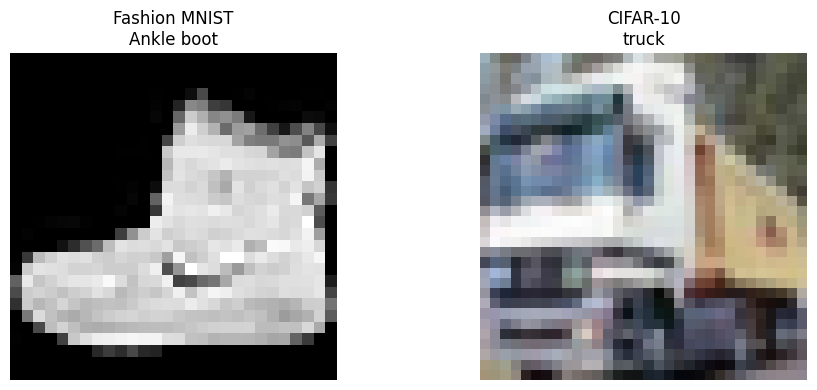

Shape gambar grayscale : (28, 28)
Pixel grayscale [0,0]  : 0

Shape gambar RGB       : (32, 32, 3)
Pixel RGB [0,0]        : [154 177 187] (R, G, B)


In [ ]:
# Visualisasi grayscale vs RGB dan cek contoh nilai pixel

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

gray_idx = 0
rgb_idx = 1

axes[0].imshow(x_train_full[gray_idx], cmap="gray")
axes[0].set_title(f"Fashion MNIST\n{fashion_class_names[y_train_full[gray_idx]]}")
axes[0].axis("off")

axes[1].imshow(xc_train[rgb_idx])
axes[1].set_title(f"CIFAR-10\n{cifar_class_names[int(yc_train[rgb_idx])]}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Shape gambar grayscale :", x_train_full[gray_idx].shape)
print("Pixel grayscale [0,0]  :", x_train_full[gray_idx][0, 0])

print("\nShape gambar RGB       :", xc_train[rgb_idx].shape)
print("Pixel RGB [0,0]        :", xc_train[rgb_idx][0, 0], "(R, G, B)")


## 10. General Flow Computer Vision

Secara sederhana, alur computer vision dapat diringkas seperti berikut:

```text
Input Gambar → Preprocessing → Feature Extraction → Decision Making
```

### Penjelasan tiap tahap

| Tahap | Penjelasan |
|---|---|
| **Input Gambar** | gambar mentah dari dataset, kamera, video, atau file |
| **Preprocessing** | normalisasi, resize, cropping, penambahan channel, dan penyesuaian format |
| **Feature Extraction** | model menangkap pola penting seperti tepi, tekstur, bentuk, dan komposisi |
| **Decision Making** | model menghasilkan output akhir, misalnya kelas gambar |

### Kenapa preprocessing penting?
Pada data visual, preprocessing membantu model melihat data dengan format yang lebih konsisten.  
Contoh sederhana:
- ukuran gambar diseragamkan,
- nilai pixel dinormalisasi,
- channel disesuaikan,
- data train/validation/test dipisahkan dengan jelas.

Di notebook workshop ini, kita akan fokus pada task **image classification** karena ini adalah pintu masuk terbaik untuk memahami alur kerja computer vision.


## 11. Menyiapkan Dataset untuk Eksperimen

Agar runtime workshop tetap nyaman, kita akan menggunakan **subset** dari Fashion MNIST.

### Kenapa Fashion MNIST?
- ukurannya ringan,
- cepat dilatih di Colab,
- cocok untuk pengenalan konsep CNN,
- tetap merupakan data visual nyata berbentuk gambar.

### Langkah preprocessing yang akan dilakukan
1. memilih subset data,
2. menormalisasi pixel dari `0–255` menjadi `0–1`,
3. menambahkan dimensi channel untuk CNN,
4. menyiapkan versi **flatten** untuk MLP,
5. membagi data menjadi **train**, **validation**, dan **test**.


In [ ]:
# Preprocessing dataset utama untuk eksperimen
MAX_TRAIN = 12000
MAX_TEST = 3000
VAL_RATIO = 0.1

x_train_small = x_train_full[:MAX_TRAIN].astype("float32") / 255.0
y_train_small = y_train_full[:MAX_TRAIN]

x_test_small = x_test_full[:MAX_TEST].astype("float32") / 255.0
y_test_small = y_test_full[:MAX_TEST]

# Versi CNN: tambahkan channel grayscale -> (H, W, 1)
x_train_cnn_all = np.expand_dims(x_train_small, axis=-1)
x_test_cnn = np.expand_dims(x_test_small, axis=-1)

# Versi MLP: flatten 28x28 -> 784
x_train_mlp_all = x_train_small.reshape(len(x_train_small), -1)
x_test_mlp = x_test_small.reshape(len(x_test_small), -1)

# Split train/validation
split_idx = int(len(x_train_small) * (1 - VAL_RATIO))

x_train_cnn = x_train_cnn_all[:split_idx]
x_val_cnn = x_train_cnn_all[split_idx:]

x_train_mlp = x_train_mlp_all[:split_idx]
x_val_mlp = x_train_mlp_all[split_idx:]

y_train_core = y_train_small[:split_idx]
y_val = y_train_small[split_idx:]

num_classes = len(fashion_class_names)

print("Train CNN shape :", x_train_cnn.shape)
print("Val CNN shape   :", x_val_cnn.shape)
print("Test CNN shape  :", x_test_cnn.shape)

print("\nTrain MLP shape :", x_train_mlp.shape)
print("Val MLP shape   :", x_val_mlp.shape)
print("Test MLP shape  :", x_test_mlp.shape)

print("\nJumlah kelas    :", num_classes)


Train CNN shape : (10800, 28, 28, 1)
Val CNN shape   : (1200, 28, 28, 1)
Test CNN shape  : (3000, 28, 28, 1)

Train MLP shape : (10800, 784)
Val MLP shape   : (1200, 784)
Test MLP shape  : (3000, 784)

Jumlah kelas    : 10


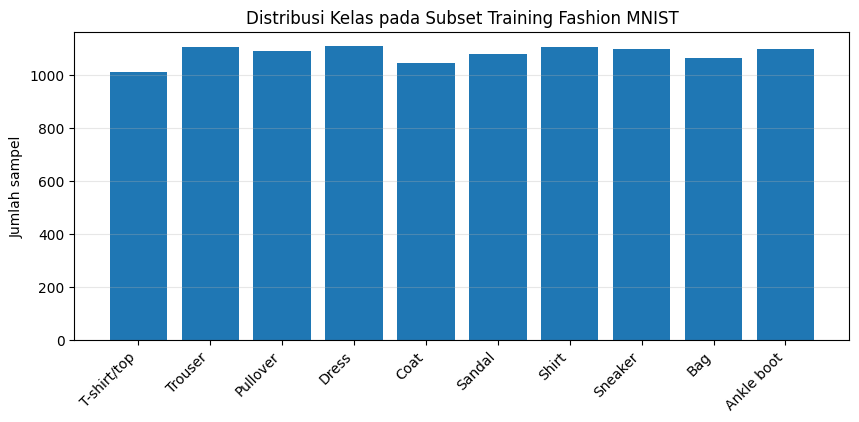

In [ ]:
# Lihat distribusi label pada subset training
counts = np.bincount(y_train_core, minlength=num_classes)

plt.figure(figsize=(10, 4))
plt.bar(range(num_classes), counts)
plt.xticks(range(num_classes), fashion_class_names, rotation=45, ha="right")
plt.title("Distribusi Kelas pada Subset Training Fashion MNIST")
plt.ylabel("Jumlah sampel")
plt.grid(axis="y", alpha=0.3)
plt.show()


## 12. Data Augmentation

Salah satu praktik penting dalam workshop computer vision adalah **data augmentation**.

Data augmentation berarti membuat variasi baru dari gambar latih, misalnya:
- rotasi kecil,
- pergeseran,
- zoom,
- flipping tertentu.

Tujuannya:
- membantu model lebih **robust**,
- mengurangi **overfitting**,
- menambah keragaman data tanpa mengumpulkan gambar baru.

Untuk Fashion MNIST, kita akan menggunakan augmentasi yang ringan agar bentuk objek tetap masuk akal.


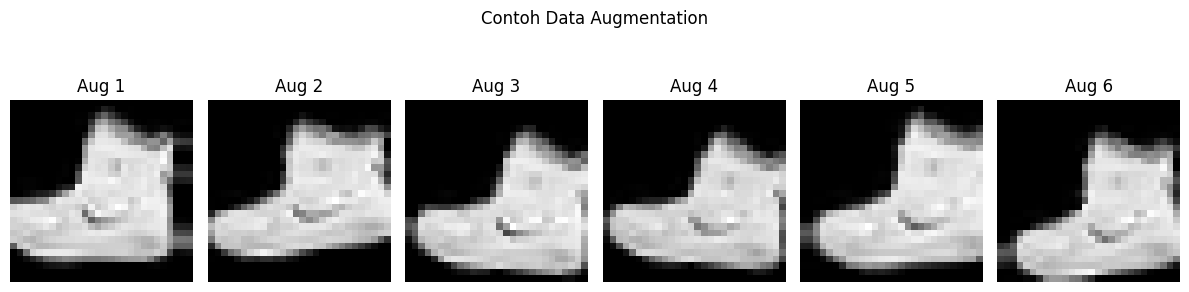

In [ ]:
# Generator augmentasi untuk data gambar
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08
)

# Fit generator pada data train
datagen.fit(x_train_cnn)

# Visualisasi beberapa hasil augmentasi dari satu gambar
sample_img = x_train_cnn[0:1]

aug_iter = datagen.flow(sample_img, batch_size=1, shuffle=False)

plt.figure(figsize=(12, 3))
for i in range(6):
    aug_img = next(aug_iter)[0].squeeze()
    plt.subplot(1, 6, i + 1)
    plt.imshow(aug_img, cmap="gray")
    plt.axis("off")
    plt.title(f"Aug {i+1}")
plt.suptitle("Contoh Data Augmentation", y=1.05)
plt.tight_layout()
plt.show()


## 13. Baseline Model: Multi Layer Perceptron (MLP)

Kita mulai dari **MLP** agar peserta melihat bahwa model dense biasa masih bisa dipakai untuk klasifikasi gambar.

Namun ada keterbatasan penting:

> MLP melihat gambar seperti **vektor panjang berisi angka**,  
> bukan sebagai struktur 2D yang punya hubungan spasial antar-pixel.

### Struktur MLP yang dipakai

| Layer | Fungsi |
|---|---|
| Input `(784,)` | hasil flatten dari gambar 28×28 |
| Dense + ReLU | belajar pola non-linear |
| Dropout | membantu mengurangi overfitting |
| Dense + Softmax | menghasilkan probabilitas 10 kelas |

MLP bagus sebagai **baseline**, tetapi untuk computer vision biasanya **CNN lebih natural**.


In [ ]:
mlp_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(784,)),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

mlp_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mlp_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Forward pass sederhana pada MLP sebelum training
sample_probs_mlp = mlp_model.predict(x_train_mlp[:3], verbose=0)

print("Shape output:", sample_probs_mlp.shape)
print("Probabilitas sampel pertama:")
print(np.round(sample_probs_mlp[0], 4))
print("Jumlah probabilitas:", np.round(sample_probs_mlp[0].sum(), 4))


Shape output: (3, 10)
Probabilitas sampel pertama:
[0.2116 0.062  0.038  0.1045 0.1581 0.0872 0.0776 0.0709 0.1352 0.0548]
Jumlah probabilitas: 1.0


In [ ]:
history_mlp = mlp_model.fit(
    x_train_mlp, y_train_core,
    validation_data=(x_val_mlp, y_val),
    epochs=3,
    batch_size=128,
    verbose=2
)

mlp_test_loss, mlp_test_acc = mlp_model.evaluate(x_test_mlp, y_test_small, verbose=0)
print(f"\nMLP test loss     : {mlp_test_loss:.4f}")
print(f"MLP test accuracy : {mlp_test_acc:.4f}")


Epoch 1/3
85/85 - 5s - 61ms/step - accuracy: 0.6900 - loss: 0.8680 - val_accuracy: 0.8042 - val_loss: 0.5566
Epoch 2/3
85/85 - 0s - 4ms/step - accuracy: 0.8064 - loss: 0.5498 - val_accuracy: 0.8358 - val_loss: 0.4767
Epoch 3/3
85/85 - 0s - 3ms/step - accuracy: 0.8269 - loss: 0.4798 - val_accuracy: 0.8425 - val_loss: 0.4516

MLP test loss     : 0.4519
MLP test accuracy : 0.8417


## 14. Kenapa CNN lebih cocok untuk gambar?

Pada slide workshop, CNN dijelaskan sebagai arsitektur deep learning yang dirancang khusus untuk data visual.

Intuisi utamanya adalah:

- **layer awal** menangkap pola sederhana seperti tepi,
- **layer tengah** mulai mengenali bentuk dan tekstur,
- **layer lebih dalam** menangkap pola visual yang lebih kompleks.

### Komponen utama CNN

| Komponen | Peran |
|---|---|
| **Convolution Layer** | mengekstraksi pola lokal dengan filter/kernel |
| **Batch Normalization** | membantu stabilitas training |
| **Activation (ReLU)** | menambahkan non-linearitas |
| **Pooling Layer** | mereduksi dimensi sambil mempertahankan fitur penting |
| **Dropout Layer** | regularisasi agar model tidak terlalu hafal data |
| **Dense Layer** | mengubah representasi fitur menjadi prediksi akhir |

### Intuisi sederhana
- **MLP** melihat gambar sebagai **daftar angka panjang**.
- **CNN** melihat gambar sebagai **struktur 2D** yang punya pola lokal.


In [ ]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    # Block 1
    tf.keras.layers.Conv2D(32, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.20),

    # Block 2
    tf.keras.layers.Conv2D(64, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    # Block 3
    tf.keras.layers.Conv2D(128, (3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.40),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,802 (3.42 MB)

 Trainable params: 897,354 (3.42 MB)

 Non-trainable params: 448 (1.75 KB)

### Demo Kode: Perubahan Shape Antar Layer dan Feature Map

Salah satu keunggulan CNN adalah kita bisa melihat bagaimana data visual berubah bentuk dari layer ke layer.

Sebagai contoh:

- input awal: `28 × 28 × 1`
- setelah convolution: menjadi beberapa **feature map**
- setelah pooling: ukuran spasial mengecil
- setelah flatten: feature map diubah menjadi vektor
- setelah dense: diubah menjadi probabilitas kelas

Mari kita cek perubahan shape-nya secara langsung.


In [ ]:
# Melihat perubahan shape antar layer CNN
sample_input = x_train_cnn[:1]

input_tensor = tf.keras.Input(shape=x_train_cnn.shape[1:])
x = input_tensor
layer_outputs_symbolic = []

for layer in cnn_model.layers:
    x = layer(x)
    layer_outputs_symbolic.append(x)

feature_extractor = tf.keras.Model(
    inputs=input_tensor,
    outputs=layer_outputs_symbolic
)

layer_outputs = feature_extractor(sample_input, training=False)

print("Input shape:", sample_input.shape)
for layer, output in zip(cnn_model.layers, layer_outputs):
    print(f"{layer.name:25s} -> {output.shape}")


Input shape: (1, 28, 28, 1)
conv2d                    -> (1, 28, 28, 32)
batch_normalization       -> (1, 28, 28, 32)
activation                -> (1, 28, 28, 32)
max_pooling2d             -> (1, 14, 14, 32)
dropout_1                 -> (1, 14, 14, 32)
conv2d_1                  -> (1, 14, 14, 64)
batch_normalization_1     -> (1, 14, 14, 64)
activation_1              -> (1, 14, 14, 64)
max_pooling2d_1           -> (1, 7, 7, 64)
dropout_2                 -> (1, 7, 7, 64)
conv2d_2                  -> (1, 7, 7, 128)
batch_normalization_2     -> (1, 7, 7, 128)
activation_2              -> (1, 7, 7, 128)
flatten                   -> (1, 6272)
dense_4                   -> (1, 128)
dropout_3                 -> (1, 128)
dense_5                   -> (1, 10)


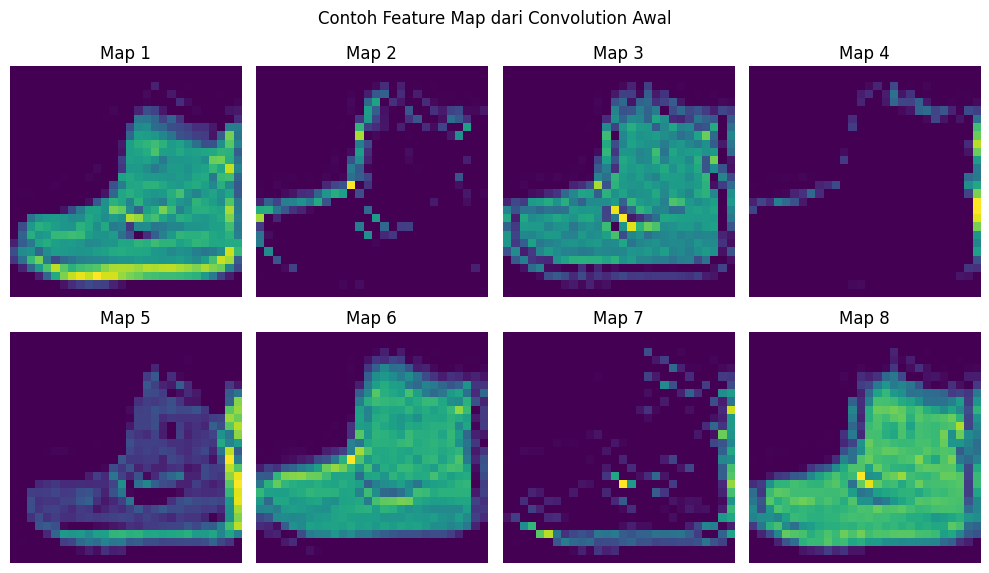

In [ ]:
# Visualisasi beberapa feature map dari convolution pertama
first_conv_model = tf.keras.Model(
    inputs=feature_extractor.input,
    outputs=feature_extractor.outputs[2]  # output setelah Activation pertama
)

feature_maps = first_conv_model(sample_input, training=False).numpy()[0]

plt.figure(figsize=(10, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[:, :, i], cmap="viridis")
    plt.axis("off")
    plt.title(f"Map {i+1}")
plt.suptitle("Contoh Feature Map dari Convolution Awal")
plt.tight_layout()
plt.show()


## 15. Training CNN dengan Callback

Pada notebook referensi workshop vision, praktik yang sangat berguna adalah memakai **callback** saat training.

Di sini kita pakai dua callback utama:

| Callback | Fungsi |
|---|---|
| `EarlyStopping` | menghentikan training jika validation loss tidak membaik |
| `ReduceLROnPlateau` | menurunkan learning rate ketika model mulai stagnan |

Karena kita juga sudah membuat **data augmentation**, training CNN akan menggunakan generator augmentasi.


In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

history_cnn = cnn_model.fit(
    datagen.flow(x_train_cnn, y_train_core, batch_size=128),
    validation_data=(x_val_cnn, y_val),
    epochs=12,
    callbacks=[early_stopping, reduce_lr],
    verbose=2
)

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_cnn, y_test_small, verbose=0)
print(f"\nCNN test loss     : {cnn_test_loss:.4f}")
print(f"CNN test accuracy : {cnn_test_acc:.4f}")


Epoch 1/12
85/85 - 21s - 246ms/step - accuracy: 0.6156 - loss: 1.0663 - val_accuracy: 0.2350 - val_loss: 2.2110 - learning_rate: 0.0010
Epoch 2/12
85/85 - 3s - 40ms/step - accuracy: 0.7228 - loss: 0.7608 - val_accuracy: 0.2108 - val_loss: 2.6142 - learning_rate: 0.0010
Epoch 3/12

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
85/85 - 3s - 41ms/step - accuracy: 0.7418 - loss: 0.6798 - val_accuracy: 0.2525 - val_loss: 2.2460 - learning_rate: 0.0010
Epoch 4/12
85/85 - 4s - 52ms/step - accuracy: 0.7644 - loss: 0.6142 - val_accuracy: 0.5017 - val_loss: 1.4627 - learning_rate: 5.0000e-04
Epoch 5/12
85/85 - 3s - 40ms/step - accuracy: 0.7792 - loss: 0.5844 - val_accuracy: 0.6942 - val_loss: 0.7170 - learning_rate: 5.0000e-04
Epoch 6/12
85/85 - 3s - 40ms/step - accuracy: 0.7803 - loss: 0.5792 - val_accuracy: 0.8167 - val_loss: 0.4996 - learning_rate: 5.0000e-04
Epoch 7/12
85/85 - 4s - 48ms/step - accuracy: 0.7883 - loss: 0.5639 - val_accuracy: 0.8475 - val_loss: 0.

## 16. Membaca Kurva Training

Visualisasi training history membantu kita membaca perilaku model:

- **loss turun** → model makin cocok dengan data,
- **accuracy naik** → prediksi makin baik,
- gap besar antara train dan validation → tanda model mulai **overfit**.


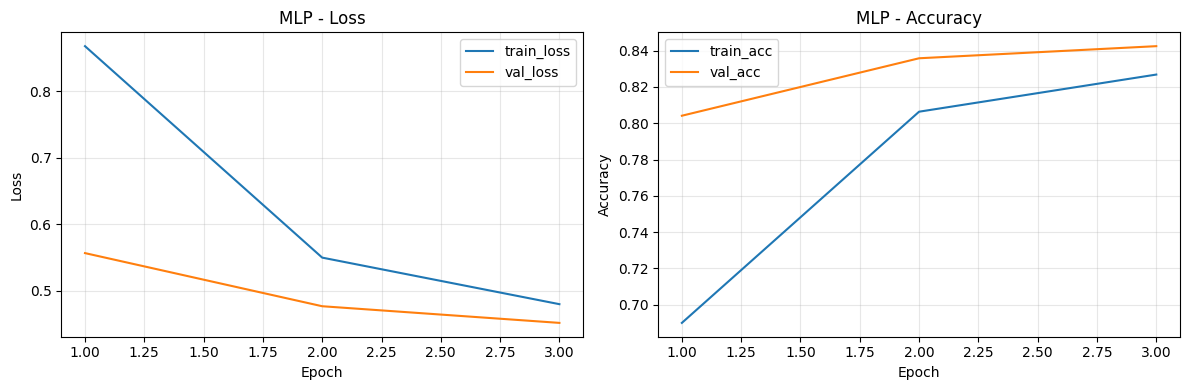

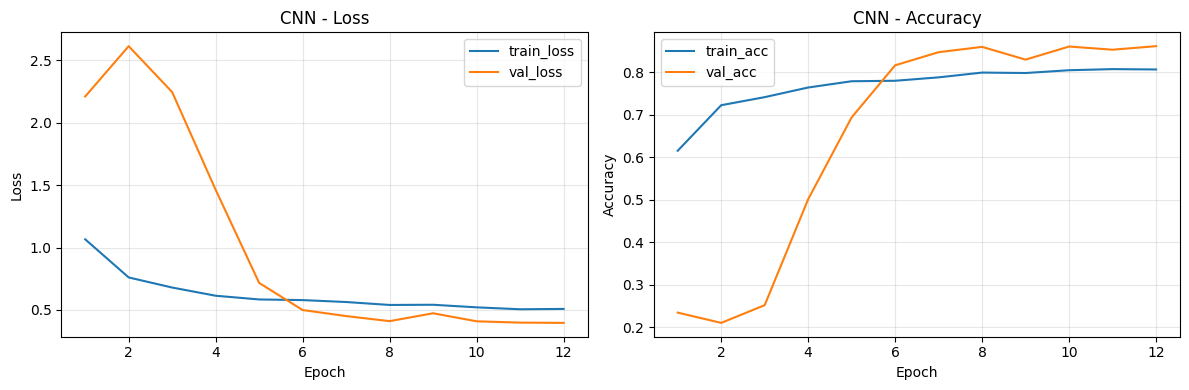

In [ ]:
def plot_history(history, title):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist["loss"], label="train_loss")
    plt.plot(epochs, hist["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist["accuracy"], label="train_acc")
    plt.plot(epochs, hist["val_accuracy"], label="val_acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history_mlp, "MLP")
plot_history(history_cnn, "CNN")


## 17. Evaluasi Model dengan Confusion Matrix

Akurasi saja sering belum cukup.

Karena itu, pada workflow computer vision kita juga perlu melihat:

- **classification report** → precision, recall, dan F1-score per kelas,
- **confusion matrix** → kelas mana yang sering tertukar.

Ini penting agar peserta memahami bahwa evaluasi model tidak berhenti di satu angka akurasi saja.


Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.79      0.83      0.81       302
     Trouser       0.98      0.98      0.98       308
    Pullover       0.77      0.80      0.79       310
       Dress       0.87      0.88      0.87       298
        Coat       0.74      0.81      0.78       324
      Sandal       0.98      0.98      0.98       285
       Shirt       0.64      0.53      0.58       298
     Sneaker       0.93      0.98      0.95       293
         Bag       0.99      0.96      0.97       297
  Ankle boot       0.98      0.93      0.96       285

    accuracy                           0.87      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.87      0.87      0.87      3000



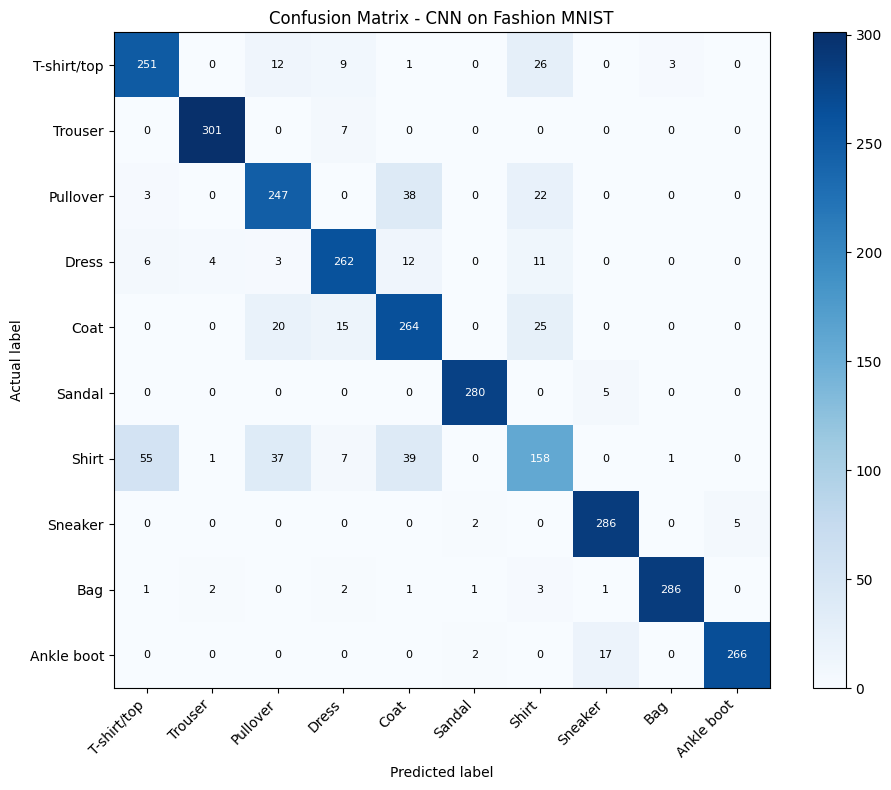

In [ ]:
# Prediksi pada test set
y_pred_probs = cnn_model.predict(x_test_cnn, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_small

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=fashion_class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - CNN on Fashion MNIST")
plt.colorbar()
plt.xticks(range(num_classes), fashion_class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), fashion_class_names)

# Tulis angka di setiap sel
threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > threshold else "black",
            fontsize=8
        )

plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()


## 18. Melihat Prediksi Model Secara Visual

Salah satu cara paling intuitif untuk memahami model vision adalah dengan **melihat hasil prediksinya langsung**.

Di bawah ini kita tampilkan:
1. beberapa sampel prediksi acak,
2. beberapa contoh **misclassified samples** agar kita bisa melihat di mana model masih bingung.


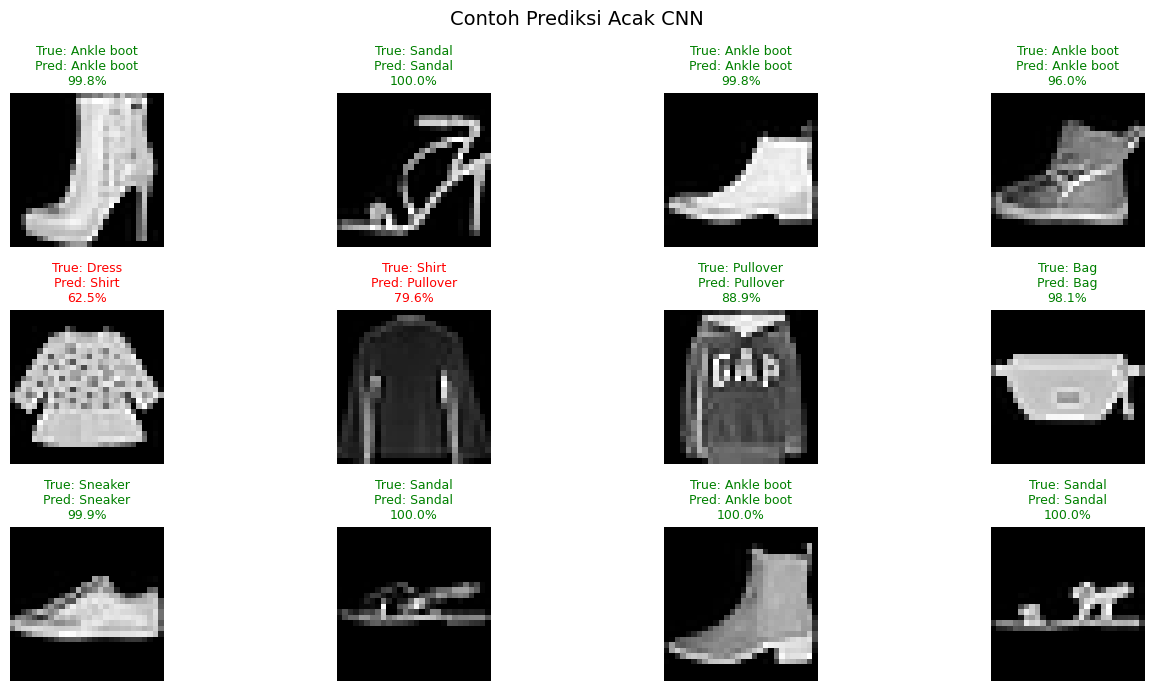

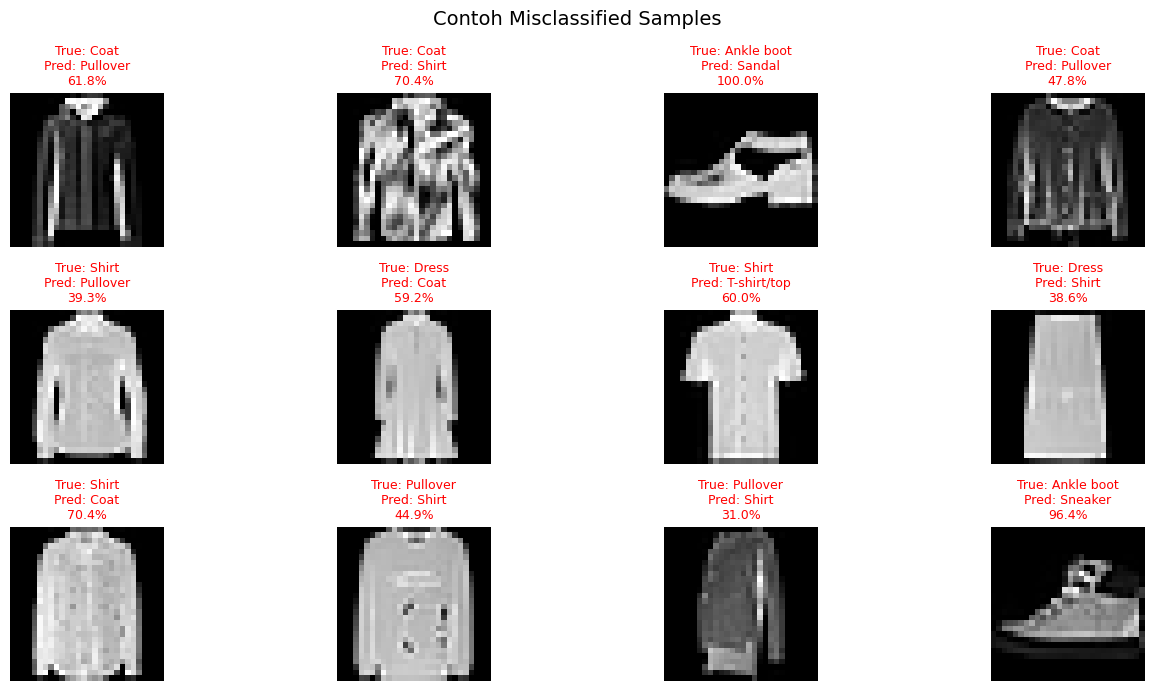

In [ ]:
# Fungsi untuk menampilkan sampel prediksi
def show_prediction_grid(images, y_true, y_pred, probs, class_names, indices, title):
    plt.figure(figsize=(14, 7))
    plt.suptitle(title, fontsize=14)

    for i, idx in enumerate(indices):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[idx].squeeze(), cmap="gray")
        true_name = class_names[y_true[idx]]
        pred_name = class_names[y_pred[idx]]
        conf = probs[idx].max() * 100

        color = "green" if y_true[idx] == y_pred[idx] else "red"
        plt.title(f"True: {true_name}\nPred: {pred_name}\n{conf:.1f}%", color=color, fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Sampel acak
random_indices = np.random.choice(len(x_test_cnn), size=12, replace=False)
show_prediction_grid(
    x_test_cnn, y_true, y_pred, y_pred_probs,
    fashion_class_names, random_indices,
    "Contoh Prediksi Acak CNN"
)

# Sampel yang salah prediksi
wrong_indices = np.where(y_true != y_pred)[0]
if len(wrong_indices) > 0:
    picked_wrong = wrong_indices[:12] if len(wrong_indices) >= 12 else wrong_indices
    show_prediction_grid(
        x_test_cnn, y_true, y_pred, y_pred_probs,
        fashion_class_names, picked_wrong,
        "Contoh Misclassified Samples"
    )
else:
    print("Tidak ada sampel salah prediksi pada subset test ini.")


## 19. Ringkasan MLP vs CNN

Sekarang kita bisa membandingkan kedua pendekatan:

| Aspek | MLP | CNN |
|---|---|---|
| Input gambar | di-*flatten* menjadi vektor | tetap dipertahankan sebagai grid 2D |
| Pemahaman pola lokal | lemah | kuat |
| Parameter | bisa sangat besar saat input besar | lebih efisien secara spasial |
| Cocok untuk vision | baseline | jauh lebih natural |

Mari kita bandingkan hasil numeriknya.


In [ ]:
print("Perbandingan performa pada test set")
print("-" * 50)
print(f"MLP | loss = {mlp_test_loss:.4f} | accuracy = {mlp_test_acc:.4f}")
print(f"CNN | loss = {cnn_test_loss:.4f} | accuracy = {cnn_test_acc:.4f}")


Perbandingan performa pada test set
--------------------------------------------------
MLP | loss = 0.4519 | accuracy = 0.8417
CNN | loss = 0.3851 | accuracy = 0.8670


## 20. Bonus Opsional: Export Model ke TensorFlow Lite

Pada workshop computer vision yang lebih lanjut, model yang sudah selesai dilatih bisa dikonversi menjadi **TensorFlow Lite (TFLite)** agar lebih ringan untuk deployment pada perangkat mobile atau edge device.

Cell di bawah ini **opsional**.  
Jalankan hanya jika kamu ingin mencoba langkah awal menuju deployment.


In [ ]:
# Opsional: konversi model CNN ke TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(cnn_model)
tflite_model = converter.convert()

tflite_path = "fashion_mnist_cnn.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"Model TFLite berhasil disimpan ke: {tflite_path}")


Saved artifact at '/tmp/tmpr98__9_s'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor_7')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  132777966025424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132777333721232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132777333726032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132777333721808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132777333721616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132777333734096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132777333722000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132777333733328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132777333732176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132777333730064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1327773337314

## 21. Tiga Task Besar dalam Computer Vision

Pada bagian akhir materi workshop, kita perlu membedakan tiga task besar berikut:

| Task | Pertanyaan yang dijawab | Output |
|---|---|---|
| **Image Classification** | “Ini gambar apa?” | satu label untuk satu gambar |
| **Object Detection** | “Objek apa saja yang ada dan di mana letaknya?” | label + bounding box |
| **Image Segmentation** | “Pixel mana milik objek tertentu?” | label per pixel |

### Contoh model populer
- **Classification**: ResNet, EfficientNet, ConvNeXt
- **Object Detection**: YOLO, RT-DETR
- **Segmentation**: U-Net, U-Net++, dan variannya

Notebook ini berfokus pada **image classification** karena task ini paling cocok untuk membangun intuisi awal peserta terhadap alur kerja deep learning pada data visual.


## 22. Kesimpulan

Dari bagian computer vision ini, ada beberapa ide utama yang perlu diingat:

1. gambar dibaca komputer sebagai **array angka**,
2. preprocessing membantu membuat data lebih konsisten untuk dipelajari,
3. **data augmentation** membantu model lebih robust,
4. **CNN** lebih cocok untuk gambar dibanding MLP karena dapat menangkap pola lokal,
5. evaluasi yang baik tidak berhenti pada akurasi, tetapi juga melihat:
   - **loss curve**,
   - **classification report**,
   - **confusion matrix**,
   - contoh prediksi yang benar dan salah,
6. model yang sudah jadi bahkan bisa dibawa lebih dekat ke deployment dengan **TensorFlow Lite**.

---

## Ide eksplorasi lanjutan
Coba modifikasi notebook ini dengan salah satu ide berikut:

- ganti optimizer dari **Adam** ke **SGD**,
- tambah 1 convolution block lagi,
- ubah tingkat augmentasi,
- jalankan eksperimen pada **CIFAR-10**,
- bandingkan CNN dengan model pretrained sederhana,
- ekspor model terbaik ke `.tflite` lalu coba inferensi pada gambar baru.

Semakin sering bereksperimen, semakin kuat intuisi kita terhadap computer vision.
